In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# ── 1. Chargement des données ───────────────────────────────────────────────────────────────

X_raw = pd.read_csv("x_test_final.csv", index_col=0)
y_raw = pd.read_csv("y_train_final_j5KGWWK.csv", index_col=0)
y_sample = pd.read_csv("y_sample_final.csv", index_col=0)   # template soumission

# On ne garde que les index communs (données labellisées)
idx = X_raw.index.intersection(y_raw.index)
X_raw = X_raw.loc[idx].copy()
y_raw = y_raw.loc[idx].copy()

print(f"Dataset : {len(X_raw)} lignes | {X_raw['date'].nunique()} jours | "
      f"{X_raw['gare'].nunique()} gares | {X_raw['train'].nunique()} trains")

# ── 2. Feature Engineering

X_raw["date"] = pd.to_datetime(X_raw["date"])

# ── Variables temporelles 
X_raw["jour_semaine"] = X_raw["date"].dt.dayofweek          # 0=Lun … 6=Dim
X_raw["mois"]         = X_raw["date"].dt.month
X_raw["semaine"]      = X_raw["date"].dt.isocalendar().week.astype(int)
X_raw["is_weekend"]   = (X_raw["jour_semaine"] >= 5).astype(int)

# ── Encodage fréquentiel gare & train

freq_gare  = X_raw["gare"].value_counts()  / len(X_raw)
freq_train = X_raw["train"].value_counts() / len(X_raw)
X_raw["freq_gare"]  = X_raw["gare"].map(freq_gare)
X_raw["freq_train"] = X_raw["train"].map(freq_train)

# ── Interaction passé : moyenne et écart-type des valeurs pq
pq_cols = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
X_raw["pq_mean"]  = X_raw[pq_cols].mean(axis=1)
X_raw["pq_std"]   = X_raw[pq_cols].std(axis=1)
X_raw["pq_max"]   = X_raw[pq_cols].max(axis=1)
X_raw["pq_min"]   = X_raw[pq_cols].min(axis=1)
# Signal de tendance : retard qui s'amplifie ou se résout ?
X_raw["trend_p"]  = X_raw["p2q0"] - X_raw["p4q0"]   # évolution sur les trains précédents
X_raw["trend_q"]  = X_raw["p0q2"] - X_raw["p0q4"]   # évolution sur les gares précédentes

FEATURES = [
    # Contexte temporel
    "jour_semaine", "mois", "semaine", "is_weekend",
    # Contexte réseau
    "arret", "freq_gare", "freq_train",
    # Valeurs passées brutes
    *pq_cols,
    # Agrégats passés
    "pq_mean", "pq_std", "pq_max", "pq_min",
    # Tendances
    "trend_p", "trend_q",
]

X = X_raw[FEATURES]
y = y_raw["p0q0"]

# ── 3. Split temporel strict 


dates_sorted = sorted(X_raw["date"].unique())
n = len(dates_sorted)
cut_val  = dates_sorted[int(n * 0.70)]
cut_test = dates_sorted[int(n * 0.85)]

mask_train = X_raw["date"] <  cut_val
mask_val   = (X_raw["date"] >= cut_val)  & (X_raw["date"] < cut_test)
mask_test  = X_raw["date"] >= cut_test

X_train, y_train = X[mask_train], y[mask_train]
X_val,   y_val   = X[mask_val],   y[mask_val]
X_test,  y_test  = X[mask_test],  y[mask_test]

print(f"\nSplit temporel :")
print(f"  Train : {len(X_train):>6} lignes  (dates < {cut_val.date()})")
print(f"  Val   : {len(X_val):>6} lignes  ({cut_val.date()} → {cut_test.date()})")
print(f"  Test  : {len(X_test):>6} lignes  (dates ≥ {cut_test.date()})")

# ── 4. Modèle

model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42,
    verbose=0,
)

model.fit(X_train, y_train)

# ── 5. Évaluation

mae_train = mean_absolute_error(y_train, model.predict(X_train))
mae_val   = mean_absolute_error(y_val,   model.predict(X_val))
mae_test  = mean_absolute_error(y_test,  model.predict(X_test))
mae_naive = mean_absolute_error(y_test,  np.zeros(len(y_test)))

print(f"\n{'Modèle':<25} {'MAE train':>10} {'MAE val':>10} {'MAE test':>10}")
print(f"{'-'*57}")
print(f"{'Naïf (prédit 0)':<25} {'--':>10} {'--':>10} {mae_naive:>10.4f}")
print(f"{'HistGradientBoosting':<25} {mae_train:>10.4f} {mae_val:>10.4f} {mae_test:>10.4f}")

gap = mae_test - mae_val
print(f"\nGap val→test : {gap:+.4f}  {'⚠ overfitting' if gap > 0.05 else '✓ stable'}")

# ── 6. Importance des features 

try:
    importances = pd.Series(model.feature_importances_, index=FEATURES)
except AttributeError:
    # HistGradientBoosting : permutation importance légère sur val
    from sklearn.inspection import permutation_importance
    r = permutation_importance(model, X_val, y_val, n_repeats=5, random_state=42,
                               scoring="neg_mean_absolute_error")
    importances = pd.Series(r.importances_mean, index=FEATURES)

importances = importances.sort_values(ascending=False)
print("\n── Importance des features ───────────────────────────────")
for feat, imp in importances.items():
    bar = "█" * max(0, int(abs(imp) * 30))
    print(f"  {feat:<15} {imp:+.4f}  {bar}")

# ── 7. Génération de la soumission


print("\n── Soumission ────────────────────────────────────────────")
print("  (remplacer X_raw par le vrai fichier x_test du challenge)")


model_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42,
)
model_final.fit(X, y)

submission = y_sample.copy()
submission["p0q0"] = model_final.predict(X).round().astype(int)
submission.to_csv("submission.csv")
print(f"  → submission.csv générée ({len(submission)} lignes)")

FileNotFoundError: [Errno 2] No such file or directory: 'x_test_final.csv'

In [4]:
import pandas as pd

# Lire le fichier CSV
x_test = pd.read_csv ("Dataset/x_test_final.csv")
x_train= pd.read_csv ("Dataset/x_train_final.csv")
y_sample = pd.read_csv ("Dataset/y_sample_final.csv")
y_train = pd.read_csv ("Dataset/y_train_final_j5KGWWK.csv")
# Afficher les 5 premières lignes de x_test
print("x_test:", x_test.head(2))
# Afficher les 5 premières lignes
print("x_train:", x_train.head(2))
print("y_sample", y_sample .head(2))
print("y_train",y_train.head(2))


x_test:    Unnamed: 0   train gare        date  arret  p2q0  p3q0  p4q0  p0q2  p0q3  \
0           0  ZPQEKP  VXY  2023-11-13     12   0.0   0.0  -2.0  -4.0  -2.0   
1           1  KIQSRA  VXY  2023-11-13     12   0.0   0.0  -1.0   1.0  -1.0   

   p0q4  
0  -4.0  
1   0.0  
x_train:    Unnamed: 0.1  Unnamed: 0   train gare        date  arret  p2q0  p3q0  p4q0  \
0             0           0  VBXNMF  KYF  2023-04-03      8   0.0   0.0   1.0   
1             1           1  VBXNMF  JLR  2023-04-03      9   0.0   0.0   0.0   

   p0q2  p0q3  p0q4  
0  -3.0  -1.0  -2.0  
1   1.0   0.0   1.0  
y_sample    Unnamed: 0  p0q0
0           0     9
1           1    -1
y_train    Unnamed: 0  p0q0
0           0  -1.0
1           1  -1.0


In [5]:
# Afficher la liste des colonnes
print("Colonnes du DataFrame :")
print(x_train.columns)

Colonnes du DataFrame :
Index(['Unnamed: 0.1', 'Unnamed: 0', 'train', 'gare', 'date', 'arret', 'p2q0',
       'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4'],
      dtype='str')


In [6]:
# 1. Compter les colonnes NUMÉRIQUES (int et float)
colonnes_numeriques = x_test.select_dtypes(include=['number']).columns
print(f"Nombre de colonnes numériques : {len(colonnes_numeriques)}")
print(f"Liste : {list(colonnes_numeriques)}")

print("-" * 30)

# 2. Compter les colonnes CATÉGORIQUES (object ou category)
colonnes_categoriques = df.select_dtypes(include=['object']).columns
print(f"Nombre de colonnes catégoriques : {len(colonnes_categoriques)}")
print(f"Liste : {list(colonnes_categoriques)}")

Nombre de colonnes numériques : 8
Liste : ['Unnamed: 0', 'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4']
------------------------------


NameError: name 'df' is not defined

In [ ]:
# Compter les valeurs manquantes par colonne
print("\nNombre de valeurs manquantes (NaN) par colonne :")
print(x_train.isna().sum())


Nombre de valeurs manquantes (NaN) par colonne :
Unnamed: 0.1    0
Unnamed: 0      0
train           0
gare            0
date            0
arret           0
p2q0            0
p3q0            0
p4q0            0
p0q2            0
p0q3            0
p0q4            0
dtype: int64


In [ ]:

#  Nombre de gares uniques (Combien on en a au total)
nb_gares_uniques = x_train['gare'].nunique()
print(f"Nombre total de gares différentes : {nb_gares_uniques}")

print("-" * 30)

#  Nombre de répétitions par gare
# Cela montre combien de fois chaque gare apparaît dans le jeu de données
repetition_gares = x_train['gare'].value_counts()

print("Top 10 des gares les plus fréquentées (les plus répétées) :")
print(repetition_gares.head(10))

# 4. Petit bonus : Statistiques sur les répétitions
print("-" * 30)
print(f"Nombre moyen de passages par gare : {repetition_gares.mean():.2f}")
print(f"Gare la moins fréquentée : {repetition_gares.idxmin()} avec {repetition_gares.min()} passage(s)")

Nombre total de gares différentes : 84
------------------------------
Top 10 des gares les plus fréquentées (les plus répétées) :
gare
JLR    31643
KYF    29737
OCB    29230
ZHN    28521
VXY    27842
EOH    26037
KCK    21449
ZFB    18559
OJA    17175
ELZ    16993
Name: count, dtype: int64
------------------------------
Nombre moyen de passages par gare : 7943.62
Gare la moins fréquentée : TXR avec 6 passage(s)


In [ ]:


# 1. Nombre de trains uniques
nb_trains_uniques = x_train['train'].nunique()
print(f"Nombre total de numéros de trains différents : {nb_trains_uniques}")

print("-" * 30)

# 2. Top 10 des trains qui apparaissent le plus souvent

repetition_trains = x_train['train'].value_counts()

print("Top 10 des trains avec le plus d'arrêts (lignes) :")
print(repetition_trains.head(10))

# 3. Statistiques sur la longueur des trajets
print("-" * 30)
print(f"Nombre moyen d'arrêts par train : {repetition_trains.mean():.1f}")
print(f"Train avec le plus long trajet : {repetition_trains.idxmax()} ({repetition_trains.max()} arrêts)")



Nombre total de numéros de trains différents : 37544
------------------------------
Top 10 des trains avec le plus d'arrêts (lignes) :
train
PBYUMJ    50
GCKHNI    31
CUFKHS    31
WAGFZE    31
ZZTQDU    31
UXXNBJ    31
UEWMYP    31
EHHYOB    31
IBQFSR    31
TKKNTW    31
Name: count, dtype: int64
------------------------------
Nombre moyen d'arrêts par train : 17.8
Train avec le plus long trajet : PBYUMJ (50 arrêts)


In [ ]:
# Top 5 des combinaisons Train + Gare les plus problématiques
top_problemes = x_test.groupby(['train', 'gare'])['p2q0'].mean().sort_values(ascending=False)
print("Combinaisons Train/Gare les plus en retard :")
print(top_problemes.head(5))

Combinaisons Train/Gare les plus en retard :
train   gare
RSDQFV  AZA     6.0
DGRHAO  EOH     5.0
SBXTGR  RUP     4.0
YXWCZU  GDN     4.0
MHARES  ARX     4.0
Name: p2q0, dtype: float64


In [ ]:
# Corrélation avec les retards du même TRAIN (en amont)
corr_train =y_train['p0q0'].corr(x_test[['p0q2', 'p0q3', 'p0q4']].mean(axis=1))

# Corrélation avec les retards de la même GARE (trains précédents)
corr_gare = y_train['p0q0'].corr(x_test[['p2q0', 'p3q0', 'p4q0']].mean(axis=1))

print(f"Influence du trajet du train : {corr_train:.2f}")
print(f"Influence de l'état de la gare : {corr_gare:.2f}")

Influence du trajet du train : 0.00
Influence de l'état de la gare : 0.00


In [ ]:
# On crée une variable qui fait la somme des retards des trains précédents à la même gare
x_test['congestion_gare'] = x_test['p2q0'] + x_test['p3q0'] + x_test['p4q0']

In [ ]:
# Tendance de retard sur le train
x_test['tendance_train'] = x_test['p0q2'] - x_test['p0q4']

In [ ]:
print("x_train",x_test.head(2))

x_train    Unnamed: 0   train gare       date  arret  p2q0  p3q0  p4q0  p0q2  p0q3  \
0           0  ZPQEKP  VXY 2023-11-13     12   0.0   0.0  -2.0  -4.0  -2.0   
1           1  KIQSRA  VXY 2023-11-13     12   0.0   0.0  -1.0   1.0  -1.0   

   p0q4 jour_nom  congestion_gare  
0  -4.0   Monday             -2.0  
1   0.0   Monday             -1.0  


In [ ]:
from tabulate import tabulate

# On choisit les colonnes qu'on veut afficher pour que ce ne soit pas trop large
cols = ['train', 'gare', 'date', 'arret', 'jour_nom', 'congestion_gare']

print(tabulate(x_test[cols].head(30), headers='keys', tablefmt='fancy_grid', showindex=False))

╒═════════╤════════╤═════════════════════╤═════════╤════════════╤═══════════════════╕
│ train   │ gare   │ date                │   arret │ jour_nom   │   congestion_gare │
╞═════════╪════════╪═════════════════════╪═════════╪════════════╪═══════════════════╡
│ ZPQEKP  │ VXY    │ 2023-11-13 00:00:00 │      12 │ Monday     │                -2 │
├─────────┼────────┼─────────────────────┼─────────┼────────────┼───────────────────┤
│ KIQSRA  │ VXY    │ 2023-11-13 00:00:00 │      12 │ Monday     │                -1 │
├─────────┼────────┼─────────────────────┼─────────┼────────────┼───────────────────┤
│ QQJYYT  │ VXY    │ 2023-11-13 00:00:00 │      12 │ Monday     │                 0 │
├─────────┼────────┼─────────────────────┼─────────┼────────────┼───────────────────┤
│ FVKYMZ  │ VXY    │ 2023-11-13 00:00:00 │      12 │ Monday     │                -1 │
├─────────┼────────┼─────────────────────┼─────────┼────────────┼───────────────────┤
│ GXNZBY  │ AZA    │ 2023-11-13 00:00:00 │      12 │ M

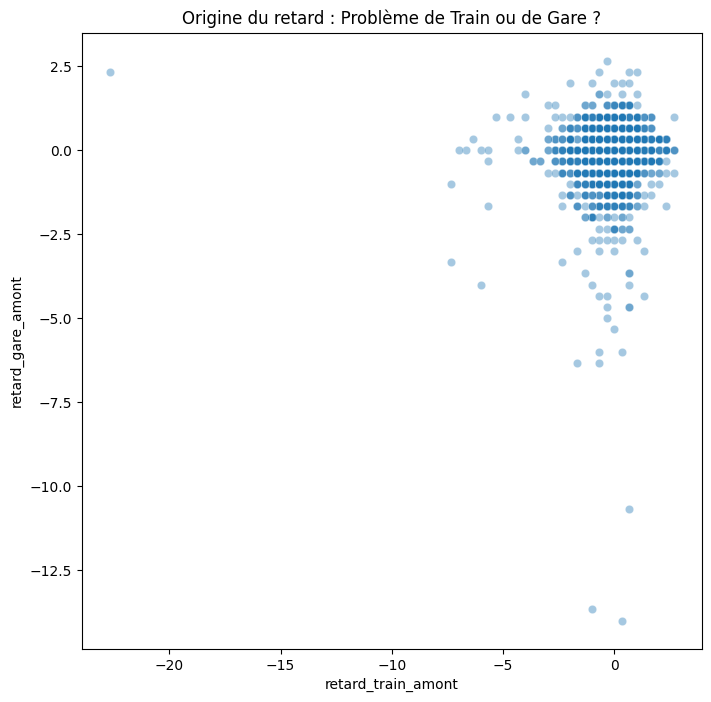

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#Scatter Plot
x_test['retard_train_amont'] = x_test[['p0q2', 'p0q3', 'p0q4']].mean(axis=1)
x_test['retard_gare_amont'] = x_test[['p2q0', 'p3q0', 'p4q0']].mean(axis=1)

plt.figure(figsize=(8, 8))
sns.scatterplot(data=x_test.sample(2000), x='retard_train_amont', y='retard_gare_amont', alpha=0.4)
plt.title("Origine du retard : Problème de Train ou de Gare ?")
plt.show()

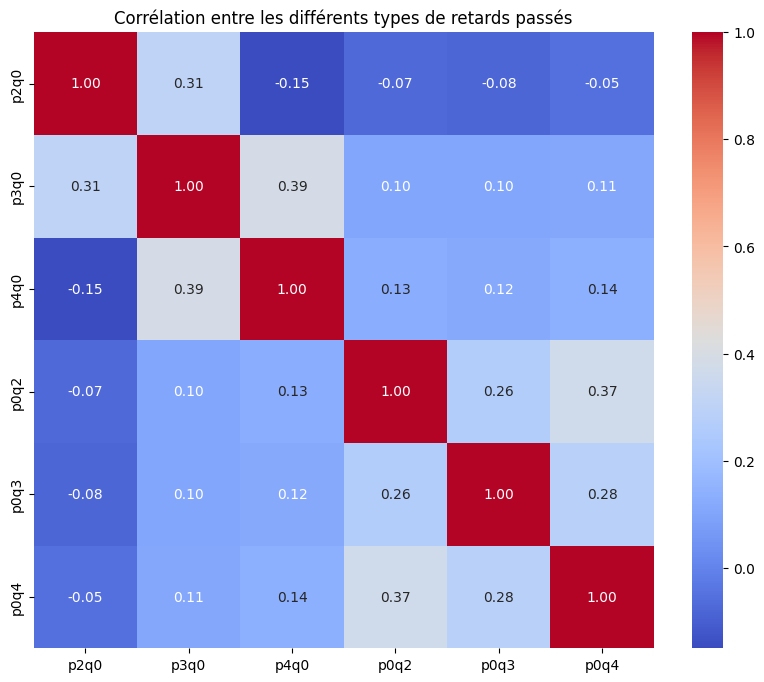

In [ ]:
lags = ['p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4']
plt.figure(figsize=(10, 8))
sns.heatmap(df[lags].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélation entre les différents types de retards passés")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

#  1. Chargement des données
X_raw = pd.read_csv("Dataset/x_test_final.csv", index_col=0)
y_raw = pd.read_csv("Dataset/y_train_final_j5KGWWK.csv", index_col=0)


# communes entre X_raw et y_raw (les indices qui se chevauchent)
common_idx = X_raw.index.intersection(y_raw.index)
X_raw = X_raw.loc[common_idx]
y_raw = y_raw.loc[common_idx]

print(f"Observations communes X / y : {len(common_idx)}")

# 2. Sélection des features

# Features numériques utilisables 
FEATURES = ["arret", "p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]

X = X_raw[FEATURES]
y = y_raw["p0q0"]

print(f"Features utilisées : {FEATURES}")
print(f"Shape X : {X.shape}, Shape y : {y.shape}")

# ── 3. Train / Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")

# ── 4. Entraînement du modèle 

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

print("\nEntraînement du Random Forest...")
model.fit(X_train, y_train)
print("Entraînement terminé.")

# ── 5. Évaluation 

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test,  y_pred_test)

print(f"\n── Résultats ──────────────────────────────")
print(f"MAE Train : {mae_train:.4f}")
print(f"MAE Test  : {mae_test:.4f}")

# Baseline naïve : prédire toujours 0 (la médiane de p0q0)
mae_naive = mean_absolute_error(y_test, np.zeros(len(y_test)))
print(f"MAE Naïve (predict 0) : {mae_naive:.4f}")
print(f"Gain vs naïve : {(1 - mae_test / mae_naive) * 100:.1f}%")

# ── 6. Importance des features 

importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

print(f"\n── Importance des features ────────────────")
for feat, imp in importances.items():
    bar = "█" * int(imp * 50)
    print(f"  {feat:<8} {imp:.4f}  {bar}")


Observations communes X / y : 20657
Features utilisées : ['arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4']
Shape X : (20657, 7), Shape y : (20657,)

Train : 16525 lignes | Test : 4132 lignes

Entraînement du Random Forest...
Entraînement terminé.

── Résultats ──────────────────────────────
MAE Train : 0.8013
MAE Test  : 0.8066
MAE Naïve (predict 0) : 0.7546
Gain vs naïve : -6.9%

── Importance des features ────────────────
  p0q2     0.1828  █████████
  p0q3     0.1676  ████████
  p3q0     0.1576  ███████
  p2q0     0.1505  ███████
  p0q4     0.1324  ██████
  p4q0     0.1242  ██████
  arret    0.0849  ████


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error

# ── 1. Chargement ─────────────────────────────────────────────────────────────

X_raw = pd.read_csv("Dataset/x_test_final.csv", index_col=0)
y_raw = pd.read_csv("Dataset/y_train_final_j5KGWWK.csv", index_col=0)

idx = X_raw.index.intersection(y_raw.index)
X_raw = X_raw.loc[idx]
y_raw = y_raw.loc[idx]

# ── 2. Features ───────────────────────────────────────────────────────────────

X_raw["date"] = pd.to_datetime(X_raw["date"])
X_raw["jour_semaine"] = X_raw["date"].dt.dayofweek
X_raw["mois"]         = X_raw["date"].dt.month
X_raw["gare_enc"]     = X_raw["gare"].astype("category").cat.codes
X_raw["train_enc"]    = X_raw["train"].astype("category").cat.codes

FEATURES = [
    "arret", "jour_semaine", "mois", "gare_enc", "train_enc",
    "p2q0", "p3q0", "p4q0",
    "p0q2", "p0q3", "p0q4",
]

X = X_raw[FEATURES]
y = y_raw["p0q0"]

# ── 3. Split Train / Validation / Test (60 / 20 / 20)

# Étape 1 : isoler le test final (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Étape 2 : couper le reste en train (75%) + val (25%) -> 60/20/20 global
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)

print(f"Train : {X_train.shape[0]} lignes  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]} lignes  ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} lignes  ({X_test.shape[0]/len(X)*100:.0f}%)")

# ── 4. Baseline rapide 

rf_base = RandomForestRegressor(
    n_estimators=100, max_depth=10,
    min_samples_leaf=5, n_jobs=-1, random_state=42
)
rf_base.fit(X_train, y_train)

mae_base_train = mean_absolute_error(y_train, rf_base.predict(X_train))
mae_base_val   = mean_absolute_error(y_val,   rf_base.predict(X_val))
mae_base_test  = mean_absolute_error(y_test,  rf_base.predict(X_test))
mae_naive      = mean_absolute_error(y_test,  np.zeros(len(y_test)))

print(f"\nBaseline RF")
print(f"  MAE train : {mae_base_train:.4f}")
print(f"  MAE val   : {mae_base_val:.4f}")
print(f"  MAE test  : {mae_base_test:.4f}")
print(f"Naive (0)   : {mae_naive:.4f}")

gap = mae_base_test - mae_base_val
print(f"Gap val->test : {gap:+.4f}  {'(overfitting probable)' if gap > 0.02 else '(stable)'}")

# ── 5. Tuning RandomizedSearch (sur train, evalue sur val)

param_dist = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [5, 8, 10, 15, None],
    "min_samples_leaf": [2, 5, 10, 20],
    "max_features":     ["sqrt", "log2", 0.5, 0.8],
}

search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

print("\nLancement RandomizedSearchCV (20 iterations, cv=3)...")
search.fit(X_train, y_train)

best = search.best_estimator_
mae_tuned_val  = mean_absolute_error(y_val,  best.predict(X_val))
mae_tuned_test = mean_absolute_error(y_test, best.predict(X_test))

print(f"\nMeilleurs parametres : {search.best_params_}")
print(f"\nRF tune")
print(f"  MAE val  : {mae_tuned_val:.4f}")
print(f"  MAE test : {mae_tuned_test:.4f}")
print(f"Gain val vs baseline : {mae_base_val - mae_tuned_val:+.4f}")

# ── 6. Importance des features ─

importances = pd.Series(best.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

print("\n── Importance des features ───────────────────")
for feat, imp in importances.items():
    bar = "X" * int(imp * 60)
    print(f"  {feat:<15} {imp:.4f}  {bar}")

# ── 7. Resume final 

print("\n── Resume ────────────────────────────────────")
print(f"  {'Modele':<20} {'MAE val':>10} {'MAE test':>10}")
print(f"  {'-'*42}")
print(f"  {'Naive (0)':<20} {'--':>10} {mae_naive:>10.4f}")
print(f"  {'RF baseline':<20} {mae_base_val:>10.4f} {mae_base_test:>10.4f}")
print(f"  {'RF tune':<20} {mae_tuned_val:>10.4f} {mae_tuned_test:>10.4f}")

best_model = best if mae_tuned_val <= mae_base_val else rf_base
print(f"\n  Modele retenu : {'RF tune' if best_model is best else 'RF baseline'}")

Train : 12393 lignes  (60%)
Val   : 4132 lignes  (20%)
Test  : 4132 lignes  (20%)

Baseline RF
  MAE train : 0.7754
  MAE val   : 0.8167
  MAE test  : 0.8115
Naive (0)   : 0.7546
Gap val->test : -0.0052  (stable)

Lancement RandomizedSearchCV (20 iterations, cv=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Meilleurs parametres : {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 5}

RF tune
  MAE val  : 0.8107
  MAE test : 0.8053
Gain val vs baseline : +0.0060

── Importance des features ───────────────────
  train_enc       0.2311  XXXXXXXXXXXXX
  gare_enc        0.1445  XXXXXXXX
  p4q0            0.1053  XXXXXX
  jour_semaine    0.0798  XXXX
  p0q2            0.0771  XXXX
  p3q0            0.0745  XXXX
  p0q3            0.0726  XXXX
  p2q0            0.0718  XXXX
  p0q4            0.0707  XXXX
  arret           0.0493  XX
  mois            0.0232  X

── Resume ────────────────────────────────────
  Modele                  MAE val 

In [ ]:
# ── 8. Sauvegarde des résultats 

# 1. Calcul des prédictions finales sur l'échantillon de test (X_test)
y_pred_final = best_model.predict(X_test)

# 2. Création d'un DataFrame de comparaison (Prédiction vs Réalité)
# Cela te permet d'ouvrir le CSV et de voir l'écart ligne par ligne
df_resultats = pd.DataFrame({
    'y_reel': y_test.values,
    'y_predit': y_pred_final
}, index=X_test.index)

# Ajout de la colonne d'erreur absolue pour analyse rapide
df_resultats['erreur_abs'] = (df_resultats['y_reel'] - df_resultats['y_predit']).abs()

# 3. Export en CSV
df_resultats.to_csv("mes_predictions_test.csv")

# 4. Format spécial pour la soumission (si nécessaire)
# Souvent, on ne demande que l'ID et la valeur prédite
df_soumission = pd.DataFrame({
    'p0q0': y_pred_final
}, index=X_test.index)
df_soumission.to_csv("soumission_final.csv")

print("\n── Sauvegarde terminée ───────────────────────")
print(f"  Fichier détaillé : mes_predictions_test.csv")
print(f"  Fichier soumission : soumission_final.csv")
print(f"  Nombre de lignes exportées : {len(df_soumission)}")


── Sauvegarde terminée ───────────────────────
  Fichier détaillé : mes_predictions_test.csv
  Fichier soumission : soumission_final.csv
  Nombre de lignes exportées : 4132


In [ ]:
# ── 9. Prédiction sur le VRAI fichier de test pour la soumission ───────────────

# 1. Charger le vrai fichier test (celui de 20 658 lignes)
X_submission_raw = pd.read_csv("Dataset/x_test_final.csv", index_col=0)

# 2. Appliquer EXACTEMENT les mêmes transformations que pour le train
X_submission_raw["date"] = pd.to_datetime(X_submission_raw["date"])
X_submission_raw["jour_semaine"] = X_submission_raw["date"].dt.dayofweek
X_submission_raw["mois"]         = X_submission_raw["date"].dt.month
X_submission_raw["gare_enc"]     = X_submission_raw["gare"].astype("category").cat.codes
X_submission_raw["train_enc"]    = X_submission_raw["train"].astype("category").cat.codes

# 3. Sélectionner les colonnes (FEATURES) dans le même ordre
X_final_task = X_submission_raw[FEATURES]

# 4. Prédire avec ton meilleur modèle
y_final_preds = best_model.predict(X_final_task)

# 5. Créer le fichier de soumission avec l'index STRICTEMENT identique
df_submission = pd.DataFrame({
    'p0q0': y_final_preds
}, index=X_submission_raw.index)

# 6. Sauvegarder (Vérifie que le nom du fichier est celui attendu par la plateforme)
df_submission.to_csv("soumission_officielle.csv")

print(f"Fichier prêt ! Nombre de lignes : {len(df_submission)}") 
# Vérifie ici que tu as bien 20 658 lignes.

Fichier prêt ! Nombre de lignes : 20657


In [12]:


import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── 1. Chargement ──────────────────────────────────────────────────────────────

X_raw   = pd.read_csv("Dataset/x_test_final.csv",           index_col=0)
y_raw   = pd.read_csv("Dataset/y_train_final_j5KGWWK.csv",  index_col=0)
y_sample = pd.read_csv("Dataset/y_sample_final.csv",         index_col=0)

# Aligner sur les index communs (données labellisées uniquement)
idx   = X_raw.index.intersection(y_raw.index)
X_raw = X_raw.loc[idx].copy()
y_raw = y_raw.loc[idx].copy()

print(f"Dataset : {len(X_raw)} lignes | {X_raw['date'].nunique()} jours | "
      f"{X_raw['gare'].nunique()} gares | {X_raw['train'].nunique()} trains")

# ── 2. Feature Engineering ─────────────────────────────────────────────────────

X_raw["date"] = pd.to_datetime(X_raw["date"])

# -- Date (seul contexte temporel disponible)
X_raw["jour_semaine"] = X_raw["date"].dt.dayofweek       # 0=Lun … 6=Dim
X_raw["mois"]         = X_raw["date"].dt.month
X_raw["semaine"]      = X_raw["date"].dt.isocalendar().week.astype(int)
X_raw["is_weekend"]   = (X_raw["jour_semaine"] >= 5).astype(int)

# -- Encodage fréquentiel gare & train
#    Donne au modèle une info sur la "densité" de trafic plutôt qu'un ID arbitraire
freq_gare  = X_raw["gare"].value_counts()  / len(X_raw)
freq_train = X_raw["train"].value_counts() / len(X_raw)
X_raw["freq_gare"]  = X_raw["gare"].map(freq_gare)
X_raw["freq_train"] = X_raw["train"].map(freq_train)

# -- Agrégats sur les valeurs passées pq
#    RF ne modélise pas les interactions automatiquement → on les crée à la main
pq_cols = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
X_raw["pq_mean"] = X_raw[pq_cols].mean(axis=1)
X_raw["pq_std"]  = X_raw[pq_cols].std(axis=1)
X_raw["pq_max"]  = X_raw[pq_cols].max(axis=1)
X_raw["pq_min"]  = X_raw[pq_cols].min(axis=1)

# -- Tendances : le retard s'amplifie ou se résorbe ?
X_raw["trend_p"] = X_raw["p2q0"] - X_raw["p4q0"]   # évolution train précédent
X_raw["trend_q"] = X_raw["p0q2"] - X_raw["p0q4"]   # évolution gare précédente

FEATURES = [
    # Contexte temporel
    "jour_semaine", "mois", "semaine", "is_weekend",
    # Contexte réseau
    "arret", "freq_gare", "freq_train",
    # Valeurs passées brutes
    *pq_cols,
    # Agrégats & tendances
    "pq_mean", "pq_std", "pq_max", "pq_min",
    "trend_p", "trend_q",
]

X = X_raw[FEATURES]
y = y_raw["p0q0"]

# ── 3. Split temporel strict ───────────────────────────────────────────────────
#
#  ┌──────────────────────────┬──────────────┬──────────────┐
#  │       TRAIN  (~70%)      │  VAL (~15%)  │  TEST (~15%) │
#  └──────────────────────────┴──────────────┴──────────────┘
#
#  On coupe par date, pas aléatoirement.
#  Un split random mélangerait passé/futur → fuite de données.

dates_sorted = sorted(X_raw["date"].unique())
n = len(dates_sorted)
cut_val  = dates_sorted[int(n * 0.70)]
cut_test = dates_sorted[int(n * 0.85)]

mask_train = X_raw["date"] < cut_val
mask_val   = (X_raw["date"] >= cut_val)  & (X_raw["date"] < cut_test)
mask_test  = X_raw["date"] >= cut_test

X_train, y_train = X[mask_train], y[mask_train]
X_val,   y_val   = X[mask_val],   y[mask_val]
X_test,  y_test  = X[mask_test],  y[mask_test]

print(f"\nSplit temporel :")
print(f"  Train : {len(X_train):>6} lignes  (dates < {cut_val.date()})")
print(f"  Val   : {len(X_val):>6} lignes  ({cut_val.date()} → {cut_test.date()})")
print(f"  Test  : {len(X_test):>6} lignes  (dates ≥ {cut_test.date()})")

# ── 4. Random Forest ───────────────────────────────────────────────────────────
#
#  Paramètres raisonnés pour ce dataset :
#
#  n_estimators=300   → au-delà de 200 le gain devient marginal, 300 est un bon
#                        compromis vitesse/variance
#  max_depth=12       → profondeur modérée : les retards de train ont un signal
#                        assez local, une forêt trop profonde sur-ajuste
#  min_samples_leaf=10 → lissage important : ~47% des labels valent 0,
#                         les feuilles trop petites mémorisent le bruit
#  max_features="sqrt" → valeur classique pour la régression, réduit la
#                         corrélation entre arbres
#  n_jobs=-1          → parallélisation sur tous les cœurs

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)

print("\nEntraînement Random Forest...")
rf.fit(X_train, y_train)

# ── 5. Évaluation 

mae_train = mean_absolute_error(y_train, rf.predict(X_train))
mae_val   = mean_absolute_error(y_val,   rf.predict(X_val))
mae_test  = mean_absolute_error(y_test,  rf.predict(X_test))
mae_naive = mean_absolute_error(y_test,  np.zeros(len(y_test)))

print(f"\n{'Modèle':<25} {'MAE train':>10} {'MAE val':>10} {'MAE test':>10}")
print(f"{'-'*57}")
print(f"{'Naïf (prédit 0)':<25} {'--':>10} {'--':>10} {mae_naive:>10.4f}")
print(f"{'Random Forest':<25} {mae_train:>10.4f} {mae_val:>10.4f} {mae_test:>10.4f}")

gap = mae_test - mae_val
print(f"\nGap val→test : {gap:+.4f}  {'⚠ overfitting' if gap > 0.05 else '✓ stable'}")

# ── 6. Importance des features ─────────────────────────────────────────────────

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("\n── Importance des features ───────────────────────────────")
for feat, imp in importances.items():
    bar = "█" * int(imp * 80)
    print(f"  {feat:<15} {imp:.4f}  {bar}")

# ── 7. Soumission finale ───────────────────────────────────────────────────────
#
#  On réentraîne sur l'intégralité des données labellisées avant de soumettre.
#  Remplacer X_raw par le vrai fichier x_test non labellisé de la plateforme.

print("\n── Soumission ────────────────────────────────────────────")
rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
rf_final.fit(X, y)

submission = y_sample.copy()
submission["p0q0"] = rf_final.predict(X).round().astype(int)
submission.to_csv("submissio.csv")
print(f"  → submission.csv générée ({len(submission)} lignes)")
print("  (remplacer X par les features du vrai x_test du challenge)")




Dataset : 20657 lignes | 24 jours | 81 gares | 8036 trains

Split temporel :
  Train :  14778 lignes  (dates < 2023-12-13)
  Val   :   2971 lignes  (2023-12-13 → 2023-12-19)
  Test  :   2908 lignes  (dates ≥ 2023-12-19)

Entraînement Random Forest...

Modèle                     MAE train    MAE val   MAE test
---------------------------------------------------------
Naïf (prédit 0)                   --         --     0.6709
Random Forest                 0.8217     0.7803     0.7472

Gap val→test : -0.0331  ✓ stable

── Importance des features ───────────────────────────────
  pq_std          0.1200  █████████
  freq_gare       0.1111  ████████
  pq_mean         0.0887  ███████
  trend_p         0.0664  █████
  jour_semaine    0.0612  ████
  p0q3            0.0565  ████
  trend_q         0.0549  ████
  p2q0            0.0493  ███
  p0q2            0.0491  ███
  p0q4            0.0484  ███
  freq_train      0.0475  ███
  p3q0            0.0450  ███
  semaine         0.0449  ███
  p4q0   

In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# ── Chargement ─────────────────────────────────────────────────────────────────

X_raw    = pd.read_csv("dataset/x_test_final.csv",          index_col=0)
y_raw    = pd.read_csv("dataset/y_train_final_j5KGWWK.csv", index_col=0)
y_sample = pd.read_csv("dataset/y_sample_final.csv",         index_col=0)

idx   = X_raw.index.intersection(y_raw.index)
X_raw = X_raw.loc[idx].copy()
y_raw = y_raw.loc[idx].copy()

# ── Features ───────────────────────────────────────────────────────────────────

X_raw["date"] = pd.to_datetime(X_raw["date"])
X_raw["jour_semaine"] = X_raw["date"].dt.dayofweek
X_raw["mois"]         = X_raw["date"].dt.month
X_raw["semaine"]      = X_raw["date"].dt.isocalendar().week.astype(int)
X_raw["is_weekend"]   = (X_raw["jour_semaine"] >= 5).astype(int)

freq_gare  = X_raw["gare"].value_counts()  / len(X_raw)
freq_train = X_raw["train"].value_counts() / len(X_raw)
X_raw["freq_gare"]  = X_raw["gare"].map(freq_gare)
X_raw["freq_train"] = X_raw["train"].map(freq_train)

pq_cols = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
X_raw["pq_mean"] = X_raw[pq_cols].mean(axis=1)
X_raw["pq_std"]  = X_raw[pq_cols].std(axis=1)
X_raw["pq_max"]  = X_raw[pq_cols].max(axis=1)
X_raw["pq_min"]  = X_raw[pq_cols].min(axis=1)
X_raw["trend_p"] = X_raw["p2q0"] - X_raw["p4q0"]
X_raw["trend_q"] = X_raw["p0q2"] - X_raw["p0q4"]

FEATURES = [
    "jour_semaine", "mois", "semaine", "is_weekend",
    "arret", "freq_gare", "freq_train",
    *pq_cols,
    "pq_mean", "pq_std", "pq_max", "pq_min",
    "trend_p", "trend_q",
]

X = X_raw[FEATURES]
y = y_raw["p0q0"]

# ── Split temporel : train sur 70% passé, prédit sur 30% futur ────────────────

dates_sorted = sorted(X_raw["date"].unique())
cut = dates_sorted[int(len(dates_sorted) * 0.70)]

mask_train = X_raw["date"] < cut
mask_test  = X_raw["date"] >= cut

X_train, y_train = X[mask_train], y[mask_train]
X_test           = X[mask_test]

print(f"Train : {len(X_train)} lignes | Test : {len(X_test)} lignes")
print(f"Coupure : {cut.date()}")

# ── Modèle ─────────────────────────────────────────────────────────────────────

model_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
model_final.fit(X_train, y_train)

# ── Soumission ─────────────────────────────────────────────────────────────────

submission = y_sample.copy()
# On remplit les index du test, le reste reste à 0
submission.loc[X_test.index, "p0q0"] = model_final.predict(X_test).round().astype(int)
submission.to_csv("submission.csv")
print(f"  → submission.csv générée ({len(submission)} lignes)")
print(f"  Distribution : {submission['p0q0'].value_counts().sort_index().to_dict()}")

Train : 14778 lignes | Test : 5879 lignes
Coupure : 2023-12-13
  → submission.csv générée (20657 lignes)
  Distribution : {-10: 656, -9: 696, -8: 685, -7: 746, -6: 711, -5: 718, -4: 738, -3: 701, -2: 727, -1: 801, 0: 6484, 1: 669, 2: 700, 3: 676, 4: 716, 5: 675, 6: 720, 7: 689, 8: 716, 9: 706, 10: 727}


In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── Chargement ─────────────────────────────────────────────────────────────────

X_raw    = pd.read_csv("dataset/x_test_final.csv",          index_col=0)
y_raw    = pd.read_csv("dataset/y_train_final_j5KGWWK.csv", index_col=0)
y_sample = pd.read_csv("dataset/y_sample_final.csv",         index_col=0)

idx   = X_raw.index.intersection(y_raw.index)
X_raw = X_raw.loc[idx].copy()
y_raw = y_raw.loc[idx].copy()

# ── Features ───────────────────────────────────────────────────────────────────

X_raw["date"] = pd.to_datetime(X_raw["date"])
X_raw["jour_semaine"] = X_raw["date"].dt.dayofweek
X_raw["mois"]         = X_raw["date"].dt.month
X_raw["semaine"]      = X_raw["date"].dt.isocalendar().week.astype(int)
X_raw["is_weekend"]   = (X_raw["jour_semaine"] >= 5).astype(int)

freq_gare  = X_raw["gare"].value_counts()  / len(X_raw)
freq_train = X_raw["train"].value_counts() / len(X_raw)
X_raw["freq_gare"]  = X_raw["gare"].map(freq_gare)
X_raw["freq_train"] = X_raw["train"].map(freq_train)

pq_cols = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
X_raw["pq_mean"] = X_raw[pq_cols].mean(axis=1)
X_raw["pq_std"]  = X_raw[pq_cols].std(axis=1)
X_raw["pq_max"]  = X_raw[pq_cols].max(axis=1)
X_raw["pq_min"]  = X_raw[pq_cols].min(axis=1)
X_raw["trend_p"] = X_raw["p2q0"] - X_raw["p4q0"]
X_raw["trend_q"] = X_raw["p0q2"] - X_raw["p0q4"]

FEATURES = [
    "jour_semaine", "mois", "semaine", "is_weekend",
    "arret", "freq_gare", "freq_train",
    *pq_cols,
    "pq_mean", "pq_std", "pq_max", "pq_min",
    "trend_p", "trend_q",
]

X = X_raw[FEATURES]
y = y_raw["p0q0"]

# ── Split temporel 70% train / 15% val / 15% test ─────────────────────────────

dates_sorted = sorted(X_raw["date"].unique())
n = len(dates_sorted)
cut_val  = dates_sorted[int(n * 0.70)]
cut_test = dates_sorted[int(n * 0.85)]

mask_train = X_raw["date"] < cut_val
mask_val   = (X_raw["date"] >= cut_val) & (X_raw["date"] < cut_test)
mask_test  = X_raw["date"] >= cut_test

X_train, y_train = X[mask_train], y[mask_train]
X_val,   y_val   = X[mask_val],   y[mask_val]
X_test,  y_test  = X[mask_test],  y[mask_test]

print(f"Train : {len(X_train)} lignes  (dates < {cut_val.date()})")
print(f"Val   : {len(X_val)} lignes  ({cut_val.date()} → {cut_test.date()})")
print(f"Test  : {len(X_test)} lignes  (dates ≥ {cut_test.date()})")

# ── Modèle ─────────────────────────────────────────────────────────────────────

model_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
model_final.fit(X_train, y_train)

# ── Scores ─────────────────────────────────────────────────────────────────────

mae_train = mean_absolute_error(y_train, model_final.predict(X_train))
mae_val   = mean_absolute_error(y_val,   model_final.predict(X_val))
mae_test  = mean_absolute_error(y_test,  model_final.predict(X_test))
mae_naive = mean_absolute_error(y_test,  np.zeros(len(y_test)))

print(f"\n{'Modèle':<20} {'MAE train':>10} {'MAE val':>10} {'MAE test':>10}")
print(f"{'-'*52}")
print(f"{'Naïf (prédit 0)':<20} {'--':>10} {'--':>10} {mae_naive:>10.4f}")
print(f"{'Random Forest':<20} {mae_train:>10.4f} {mae_val:>10.4f} {mae_test:>10.4f}")

gap = mae_test - mae_val
print(f"\nGap val→test : {gap:+.4f}  {'⚠ overfitting' if gap > 0.05 else '✓ stable'}")

# ── Soumission (entraîné sur train, prédit sur test) ───────────────────────────

submission = y_sample.copy()
submission.loc[X_test.index, "p0q0"] = model_final.predict(X_test).round().astype(int)
submission.to_csv("submission.csv")
print(f"\n  → submission.csv générée ({len(submission)} lignes)")
print(f"  Distribution : {submission['p0q0'].value_counts().sort_index().to_dict()}")

Train : 14778 lignes  (dates < 2023-12-13)
Val   : 2971 lignes  (2023-12-13 → 2023-12-19)
Test  : 2908 lignes  (dates ≥ 2023-12-19)

Modèle                MAE train    MAE val   MAE test
----------------------------------------------------
Naïf (prédit 0)              --         --     0.6709
Random Forest            0.8217     0.7803     0.7472

Gap val→test : -0.0331  ✓ stable

  → submission.csv générée (20657 lignes)
  Distribution : {-10: 802, -9: 831, -8: 827, -7: 866, -6: 866, -5: 862, -4: 881, -3: 856, -2: 849, -1: 907, 0: 3681, 1: 796, 2: 845, 3: 832, 4: 869, 5: 825, 6: 880, 7: 823, 8: 849, 9: 860, 10: 850}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── Chargement ─────────────────────────────────────────────────────────────────

X_test_raw  = pd.read_csv("x_test_final.csv",          index_col=0)
y_raw       = pd.read_csv("y_train_final_j5KGWWK.csv", index_col=0)
y_sample    = pd.read_csv("y_sample_final.csv",         index_col=0)

# Aligner y sur x_test (données labellisées)
idx        = X_test_raw.index.intersection(y_raw.index)
X_test_raw = X_test_raw.loc[idx].copy()
y_train    = y_raw.loc[idx, "p0q0"]

# ── Feature Engineering ────────────────────────────────────────────────────────

def add_features(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    # One-hot jour de la semaine (lundi=[1,0,0,0,0,0,0] ... dimanche=[0,0,0,0,0,0,1])
    jour = df["date"].dt.dayofweek
    for i, nom in enumerate(["lun", "mar", "mer", "jeu", "ven", "sam", "dim"]):
        df[f"jour_{nom}"] = (jour == i).astype(int)

    df["mois"]    = df["date"].dt.month
    df["semaine"] = df["date"].dt.isocalendar().week.astype(int)

    freq_gare  = df["gare"].value_counts()  / len(df)
    freq_train = df["train"].value_counts() / len(df)
    df["freq_gare"]  = df["gare"].map(freq_gare).fillna(0)
    df["freq_train"] = df["train"].map(freq_train).fillna(0)

    pq_cols = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
    df["pq_mean"] = df[pq_cols].mean(axis=1)
    df["pq_std"]  = df[pq_cols].std(axis=1)
    df["pq_max"]  = df[pq_cols].max(axis=1)
    df["pq_min"]  = df[pq_cols].min(axis=1)
    df["trend_p"] = df["p2q0"] - df["p4q0"]
    df["trend_q"] = df["p0q2"] - df["p0q4"]

    return df

X_test_raw = add_features(X_test_raw)

FEATURES = [
    "jour_lun", "jour_mar", "jour_mer", "jour_jeu", "jour_ven", "jour_sam", "jour_dim",
    "mois", "semaine",
    "arret", "freq_gare", "freq_train",
    "p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4",
    "pq_mean", "pq_std", "pq_max", "pq_min", "trend_p", "trend_q",
]

X = X_test_raw[FEATURES]
y = y_train

# ── Split temporel 70% train / 15% val / 15% test ─────────────────────────────

dates_sorted = sorted(X_test_raw["date"].unique())
n        = len(dates_sorted)
cut_val  = dates_sorted[int(n * 0.70)]
cut_test = dates_sorted[int(n * 0.85)]

mask_train = X_test_raw["date"] < cut_val
mask_val   = (X_test_raw["date"] >= cut_val) & (X_test_raw["date"] < cut_test)
mask_test  = X_test_raw["date"] >= cut_test

X_tr,  y_tr  = X[mask_train], y[mask_train]
X_val, y_val = X[mask_val],   y[mask_val]
X_te,  y_te  = X[mask_test],  y[mask_test]

print(f"Train : {len(X_tr)} lignes  (dates < {cut_val.date()})")
print(f"Val   : {len(X_val)} lignes  ({cut_val.date()} → {cut_test.date()})")
print(f"Test  : {len(X_te)} lignes  (dates ≥ {cut_test.date()})")

# ── Modèle ─────────────────────────────────────────────────────────────────────

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
model.fit(X_tr, y_tr)

# ── Scores ─────────────────────────────────────────────────────────────────────

mae_train = mean_absolute_error(y_tr,  model.predict(X_tr))
mae_val   = mean_absolute_error(y_val, model.predict(X_val))
mae_test  = mean_absolute_error(y_te,  model.predict(X_te))
mae_naive = mean_absolute_error(y_te,  np.zeros(len(y_te)))

print(f"\n{'Modèle':<20} {'MAE train':>10} {'MAE val':>10} {'MAE test':>10}")
print(f"{'-'*52}")
print(f"{'Naïf (prédit 0)':<20} {'--':>10} {'--':>10} {mae_naive:>10.4f}")
print(f"{'Random Forest':<20} {mae_train:>10.4f} {mae_val:>10.4f} {mae_test:>10.4f}")

gap = mae_test - mae_val
print(f"\nGap val→test : {gap:+.4f}  {'⚠ overfitting' if gap > 0.05 else '✓ stable'}")

# ── Soumission (réentraîné sur tout) ───────────────────────────────────────────

model_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
model_final.fit(X, y)

submission = y_sample.copy()
submission.loc[X_te.index, "p0q0"] = model_final.predict(X_te).round().astype(int)
submission.to_csv("submission.csv")
print(f"\n  → submission.csv générée ({len(submission)} lignes)")
print(f"  Distribution : {submission['p0q0'].value_counts().sort_index().to_dict()}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── Chargement ─────────────────────────────────────────────────────────────────

X_raw    = pd.read_csv("Dataset/x_test_final.csv",          index_col=0)
y_raw    = pd.read_csv("Dataset/y_train_final_j5KGWWK.csv", index_col=0)

idx   = X_raw.index.intersection(y_raw.index)
X_raw = X_raw.loc[idx].copy()
y_raw = y_raw.loc[idx].copy()

# ── Feature Engineering ────────────────────────────────────────────────────────

def add_features(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    # One-hot jour de la semaine (lundi=[1,0,0,0,0,0,0] ... dimanche=[0,0,0,0,0,0,1])
    jour = df["date"].dt.dayofweek
    for i, nom in enumerate(["lun", "mar", "mer", "jeu", "ven", "sam", "dim"]):
        df[f"jour_{nom}"] = (jour == i).astype(int)

    df["mois"]    = df["date"].dt.month
    df["semaine"] = df["date"].dt.isocalendar().week.astype(int)

    freq_gare  = df["gare"].value_counts()  / len(df)
    freq_train = df["train"].value_counts() / len(df)
    df["freq_gare"]  = df["gare"].map(freq_gare).fillna(0)
    df["freq_train"] = df["train"].map(freq_train).fillna(0)

    pq_cols = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
    df["pq_mean"] = df[pq_cols].mean(axis=1)
    df["pq_std"]  = df[pq_cols].std(axis=1)
    df["pq_max"]  = df[pq_cols].max(axis=1)
    df["pq_min"]  = df[pq_cols].min(axis=1)
    df["trend_p"] = df["p2q0"] - df["p4q0"]
    df["trend_q"] = df["p0q2"] - df["p0q4"]

    return df

X_raw = add_features(X_raw)

FEATURES = [
    "jour_lun", "jour_mar", "jour_mer", "jour_jeu", "jour_ven", "jour_sam", "jour_dim",
    "mois", "semaine",
    "arret", "freq_gare", "freq_train",
    "p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4",
    "pq_mean", "pq_std", "pq_max", "pq_min", "trend_p", "trend_q",
]

X = X_raw[FEATURES]
y = y_raw["p0q0"]

# ── Split temporel 70% train / 15% val / 15% test ─────────────────────────────

dates_sorted = sorted(X_raw["date"].unique())
n        = len(dates_sorted)
cut_val  = dates_sorted[int(n * 0.70)]
cut_test = dates_sorted[int(n * 0.85)]

mask_train = X_raw["date"] < cut_val
mask_val   = (X_raw["date"] >= cut_val) & (X_raw["date"] < cut_test)
mask_test  = X_raw["date"] >= cut_test

X_tr,  y_tr  = X[mask_train], y[mask_train]
X_val, y_val = X[mask_val],   y[mask_val]
X_te,  y_te  = X[mask_test],  y[mask_test]

print(f"Train : {len(X_tr)} lignes  (dates < {cut_val.date()})")
print(f"Val   : {len(X_val)} lignes  ({cut_val.date()} → {cut_test.date()})")
print(f"Test  : {len(X_te)} lignes  (dates ≥ {cut_test.date()})")

# ── Modèle ─────────────────────────────────────────────────────────────────────

model = RandomForestRegressor(
    criterion="absolute_error",
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
model.fit(X_tr, y_tr)

# ── Scores MAE ─────────────────────────────────────────────────────────────────

mae_train = mean_absolute_error(y_tr,  model.predict(X_tr))
mae_val   = mean_absolute_error(y_val, model.predict(X_val))
mae_test  = mean_absolute_error(y_te,  model.predict(X_te))
mae_naive = mean_absolute_error(y_te,  np.zeros(len(y_te)))

print(f"\n{'Modèle':<20} {'MAE train':>10} {'MAE val':>10} {'MAE test':>10}")
print(f"{'-'*52}")
print(f"{'Naïf (prédit 0)':<20} {'--':>10} {'--':>10} {mae_naive:>10.4f}")
print(f"{'Random Forest':<20} {mae_train:>10.4f} {mae_val:>10.4f} {mae_test:>10.4f}")

gap = mae_test - mae_val
print(f"\nGap val→test : {gap:+.4f}  {'overfitting' if gap > 0.05 else 'stable'}")

# ── Soumission ─────────────────────────────────────────────────────────────────

submission = y_raw.loc[X_te.index].copy()
submission["p0q0"] = model.predict(X_te).round().astype(int)
submission.to_csv("submission22.csv")
print(f"\n  → submission22.csv générée ({len(submission)} lignes)")
print(f"  Distribution : {submission['p0q0'].value_counts().sort_index().to_dict()}")

Train : 14778 lignes  (dates < 2023-12-13)
Val   : 2971 lignes  (2023-12-13 → 2023-12-19)
Test  : 2908 lignes  (dates ≥ 2023-12-19)

Modèle                MAE train    MAE val   MAE test
----------------------------------------------------
Naïf (prédit 0)              --         --     0.6709
Random Forest            0.7932     0.7039     0.6796

Gap val→test : -0.0243  ✓ stable

  → submission22.csv générée (2908 lignes)
  Distribution : {0: 2908}


In [25]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── Chargement ─────────────────────────────────────────────────────────────────

X_raw = pd.read_csv("dataset/x_test_final.csv",          index_col=0)
y_raw = pd.read_csv("dataset/x_train_final.csv", index_col=0)

idx   = X_raw.index.intersection(y_raw.index)
X_raw = X_raw.loc[idx].copy()
y_raw = y_raw.loc[idx].copy()

# ── Feature Engineering ────────────────────────────────────────────────────────

def add_features(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    jour = df["date"].dt.dayofweek
    for i, nom in enumerate(["lun", "mar", "mer", "jeu", "ven", "sam", "dim"]):
        df[f"jour_{nom}"] = (jour == i).astype(int)

    df["mois"]    = df["date"].dt.month
    df["semaine"] = df["date"].dt.isocalendar().week.astype(int)

    freq_gare  = df["gare"].value_counts()  / len(df)
    freq_train = df["train"].value_counts() / len(df)
    df["freq_gare"]  = df["gare"].map(freq_gare).fillna(0)
    df["freq_train"] = df["train"].map(freq_train).fillna(0)

    pq_cols = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
    df["pq_mean"] = df[pq_cols].mean(axis=1)
    df["pq_std"]  = df[pq_cols].std(axis=1)
    df["pq_max"]  = df[pq_cols].max(axis=1)
    df["pq_min"]  = df[pq_cols].min(axis=1)
    df["trend_p"] = df["p2q0"] - df["p4q0"]
    df["trend_q"] = df["p0q2"] - df["p0q4"]

    return df

X_raw = add_features(X_raw)

FEATURES = [
    "jour_lun", "jour_mar", "jour_mer", "jour_jeu", "jour_ven", "jour_sam", "jour_dim",
    "mois", "semaine",
    "arret", "freq_gare", "freq_train",
    "p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4",
    "pq_mean", "pq_std", "pq_max", "pq_min", "trend_p", "trend_q",
]

X = X_raw[FEATURES]
y = y_raw["p0q0"]

# ── Split temporel 70% train / 15% val / 15% test ─────────────────────────────

dates_sorted = sorted(X_raw["date"].unique())
n        = len(dates_sorted)
cut_val  = dates_sorted[int(n * 0.70)]
cut_test = dates_sorted[int(n * 0.85)]

mask_train = X_raw["date"] < cut_val
mask_val   = (X_raw["date"] >= cut_val) & (X_raw["date"] < cut_test)
mask_test  = X_raw["date"] >= cut_test

X_tr,  y_tr  = X[mask_train], y[mask_train]
X_val, y_val = X[mask_val],   y[mask_val]
X_te,  y_te  = X[mask_test],  y[mask_test]

print(f"Train : {len(X_tr)} lignes  (dates < {cut_val.date()})")
print(f"Val   : {len(X_val)} lignes  ({cut_val.date()} → {cut_test.date()})")
print(f"Test  : {len(X_te)} lignes  (dates ≥ {cut_test.date()})")

# ── Modèle (paramètres ajustés pour éviter les 0 partout) ─────────────────────

model = RandomForestRegressor(
    criterion="absolute_error",
    n_estimators=500,
    max_depth=20,          # plus profond → prédictions plus précises
    min_samples_leaf=1,    # ← clé : autorise des feuilles à 1 observation
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
model.fit(X_tr, y_tr)

# ── Scores MAE ─────────────────────────────────────────────────────────────────

mae_train = mean_absolute_error(y_tr,  model.predict(X_tr))
mae_val   = mean_absolute_error(y_val, model.predict(X_val))
mae_test  = mean_absolute_error(y_te,  model.predict(X_te))
mae_naive = mean_absolute_error(y_te,  np.zeros(len(y_te)))

print(f"\n{'Modèle':<20} {'MAE train':>10} {'MAE val':>10} {'MAE test':>10}")
print(f"{'-'*52}")
print(f"{'Naïf (prédit 0)':<20} {'--':>10} {'--':>10} {mae_naive:>10.4f}")
print(f"{'Random Forest':<20} {mae_train:>10.4f} {mae_val:>10.4f} {mae_test:>10.4f}")

gap = mae_test - mae_val
print(f"\nGap val→test : {gap:+.4f}  {'⚠ overfitting' if gap > 0.05 else '✓ stable'}")

# ── Soumission ─────────────────────────────────────────────────────────────────

submission = y_raw.loc[X_te.index].copy()
submission["p0q0"] = model.predict(X_te).round().astype(int)
submission.to_csv("submission3.csv")
print(f"\n  → submission3.csv générée ({len(submission)} lignes)")
print(f"  Distribution : {submission['p0q0'].value_counts().sort_index().to_dict()}")

KeyError: 'p0q0'

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── Chargement ─────────────────────────────────────────────────────────────────

X_raw = pd.read_csv("dataset/x_test_final.csv",          index_col=0)
y_raw = pd.read_csv("dataset/y_train_final_j5KGWWK.csv", index_col=0)

idx   = X_raw.index.intersection(y_raw.index)
X_raw = X_raw.loc[idx].copy()
y_raw = y_raw.loc[idx].copy()

# ── Feature Engineering ────────────────────────────────────────────────────────

def add_features(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    jour = df["date"].dt.dayofweek
    for i, nom in enumerate(["lun", "mar", "mer", "jeu", "ven", "sam", "dim"]):
        df[f"jour_{nom}"] = (jour == i).astype(int)

    df["mois"]    = df["date"].dt.month
    df["semaine"] = df["date"].dt.isocalendar().week.astype(int)

    freq_gare  = df["gare"].value_counts()  / len(df)
    freq_train = df["train"].value_counts() / len(df)
    df["freq_gare"]  = df["gare"].map(freq_gare).fillna(0)
    df["freq_train"] = df["train"].map(freq_train).fillna(0)

    pq_cols = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
    df["pq_mean"] = df[pq_cols].mean(axis=1)
    df["pq_std"]  = df[pq_cols].std(axis=1)
    df["pq_max"]  = df[pq_cols].max(axis=1)
    df["pq_min"]  = df[pq_cols].min(axis=1)
    df["trend_p"] = df["p2q0"] - df["p4q0"]
    df["trend_q"] = df["p0q2"] - df["p0q4"]

    return df

X_raw = add_features(X_raw)

FEATURES = [
    "jour_lun", "jour_mar", "jour_mer", "jour_jeu", "jour_ven", "jour_sam", "jour_dim",
    "mois", "semaine",
    "arret", "freq_gare", "freq_train",
    "p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4",
    "pq_mean", "pq_std", "pq_max", "pq_min", "trend_p", "trend_q",
]

X = X_raw[FEATURES]
y = y_raw["p0q0"]

# ── Split temporel 70% train / 15% val / 15% test ─────────────────────────────

dates_sorted = sorted(X_raw["date"].unique())
n        = len(dates_sorted)
cut_val  = dates_sorted[int(n * 0.70)]
cut_test = dates_sorted[int(n * 0.85)]

mask_train = X_raw["date"] < cut_val
mask_val   = (X_raw["date"] >= cut_val) & (X_raw["date"] < cut_test)
mask_test  = X_raw["date"] >= cut_test

X_tr,  y_tr  = X[mask_train], y[mask_train]
X_val, y_val = X[mask_val],   y[mask_val]
X_te,  y_te  = X[mask_test],  y[mask_test]

print(f"Train : {len(X_tr)} lignes  (dates < {cut_val.date()})")
print(f"Val   : {len(X_val)} lignes  ({cut_val.date()} → {cut_test.date()})")
print(f"Test  : {len(X_te)} lignes  (dates ≥ {cut_test.date()})")

# ── Modèle (paramètres ajustés pour éviter les 0 partout) ─────────────────────

model = RandomForestRegressor(
    criterion="absolute_error",
    n_estimators=500,
    max_depth=20,          # plus profond → prédictions plus précises
    min_samples_leaf=1,    # ← clé : autorise des feuilles à 1 observation
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
)
model.fit(X_tr, y_tr)

# ── Scores MAE ─────────────────────────────────────────────────────────────────

mae_train = mean_absolute_error(y_tr,  model.predict(X_tr))
mae_val   = mean_absolute_error(y_val, model.predict(X_val))
mae_test  = mean_absolute_error(y_te,  model.predict(X_te))
mae_naive = mean_absolute_error(y_te,  np.zeros(len(y_te)))

print(f"\n{'Modèle':<20} {'MAE train':>10} {'MAE val':>10} {'MAE test':>10}")
print(f"{'-'*52}")
print(f"{'Naïf (prédit 0)':<20} {'--':>10} {'--':>10} {mae_naive:>10.4f}")
print(f"{'Random Forest':<20} {mae_train:>10.4f} {mae_val:>10.4f} {mae_test:>10.4f}")

gap = mae_test - mae_val
print(f"\nGap val→test : {gap:+.4f}  {'⚠ overfitting' if gap > 0.05 else '✓ stable'}")

# ── Soumission ─────────────────────────────────────────────────────────────────

submission = y_raw.loc[X_te.index].copy()
submission["p0q0"] = model.predict(X_te).round().astype(int)
submission.to_csv("submission3.csv")
print(f"\n  → submission3.csv générée ({len(submission)} lignes)")
print(f"  Distribution : {submission['p0q0'].value_counts().sort_index().to_dict()}")

Train : 14778 lignes  (dates < 2023-12-13)
Val   : 2971 lignes  (2023-12-13 → 2023-12-19)
Test  : 2908 lignes  (dates ≥ 2023-12-19)

Modèle                MAE train    MAE val   MAE test
----------------------------------------------------
Naïf (prédit 0)              --         --     0.6709
Random Forest            0.7837     0.7027     0.6792

Gap val→test : -0.0236  ✓ stable

  → submission3.csv générée (2908 lignes)
  Distribution : {-1: 5, 0: 2903}


In [27]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── 1. Chargement correct ──────────────────────────────────────────────────
# On entraîne sur TRAIN, on prédit sur TEST
X_train_raw = pd.read_csv("dataset/x_train_final.csv", index_col=0)
y_train_raw = pd.read_csv("dataset/y_train_final_j5KGWWK.csv", index_col=0)
X_test_prod = pd.read_csv("dataset/x_test_final.csv", index_col=0)

# ── 2. Feature Engineering ─────────────────────────────────────────────────
def add_features(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["hour"] = df["arret"] # Si 'arret' représente l'heure ou la séquence
    df["dayofweek"] = df["date"].dt.dayofweek
    
    # Interaction entre le passé train (p) et le passé gare (q)
    df["p_mean"] = df[["p2q0", "p3q0", "p4q0"]].mean(axis=1)
    df["q_mean"] = df[["p0q2", "p0q3", "p0q4"]].mean(axis=1)
    df["diff_pq"] = df["p_mean"] - df["q_mean"]
    
    return df

X_train_raw = add_features(X_train_raw)
X_test_prod = add_features(X_test_prod)

FEATURES = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4", 
            "p_mean", "q_mean", "diff_pq", "dayofweek", "arret"]

X_train = X_train_raw[FEATURES]
y_train = y_train_raw["p0q0"]
X_test  = X_test_prod[FEATURES]

# ── 3. Modèle robuste ──────────────────────────────────────────────────────
# Utiliser squared_error permet de mieux capter les écarts à 0
model = RandomForestRegressor(
    n_estimators=100, 
    criterion="squared_error", 
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

print("Entraînement en cours...")
model.fit(X_train, y_train)

# ── 4. Prédiction et Soumission ───────────────────────────────────────────
preds = model.predict(X_test)

# Pour éviter que tout soit à 0, on vérifie la distribution
print(f"Moyenne des prédictions : {preds.mean():.4f}")
print(f"Nb de valeurs non-nulles : {np.count_nonzero(np.round(preds))}")

submission = pd.DataFrame({
    "p0q0": np.round(preds).astype(int)
}, index=X_test_prod.index)

submission.to_csv("submission_fi.csv")

Entraînement en cours...
Moyenne des prédictions : -0.2334
Nb de valeurs non-nulles : 8692
